# Predicting Power Plant Energy Output
A supervised regression model that predicts the net hourly electrical energy output (PE) of a Combined Cycle Power Plant from four environmental sensor readings.

**Author:** Rahama Saleh

## 1. Load the data
9,568 hourly readings: Ambient Temperature (AT), Exhaust Vacuum (V), Ambient Pressure (AP), Relative Humidity (RH) and the target, Energy Output (PE).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

df = pd.read_csv("CCPP_data.csv")
print("Rows:", len(df))
df.head()

Rows: 9568


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


## 2. Feature selection
Correlation of each feature with energy output.

In [2]:
df.corr()["PE"].round(3)

AT   -0.948
V    -0.870
AP    0.518
RH    0.390
PE    1.000
Name: PE, dtype: float64

## 3. Train and test split
80% for building models, 20% held back as an untouched test set.

In [3]:
X, y = df[["AT", "V", "AP", "RH"]], df["PE"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training rows:", len(X_train), "| Test rows:", len(X_test))

Training rows: 7654 | Test rows: 1914


## 4. Model comparison with five fold cross validation
Metric: Mean Absolute Error (MAE) in MW. Lower is better.

In [4]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "Linear Regression (AT only)": (LinearRegression(), ["AT"]),
    "Linear Regression (all 4 features)": (LinearRegression(), ["AT", "V", "AP", "RH"]),
    "Random Forest (all 4 features)": (RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1), ["AT", "V", "AP", "RH"]),
}
results = {}
for name, (model, feats) in models.items():
    scores = -cross_val_score(model, X_train[feats], y_train, cv=kf, scoring="neg_mean_absolute_error")
    results[name] = scores.mean()
    print(f"{name}: {scores.mean():.2f} MW (+/- {scores.std():.2f})")

best = min(results, key=results.get)
print("\nBest model:", best)

Linear Regression (AT only): 4.29 MW (+/- 0.08)
Linear Regression (all 4 features): 3.63 MW (+/- 0.05)


Random Forest (all 4 features): 2.47 MW (+/- 0.07)

Best model: Random Forest (all 4 features)


## 5. Final evaluation on the test set

MAE:  2.32 MW
RMSE: 3.23 MW
MAPE: 0.51%
R2:   0.964


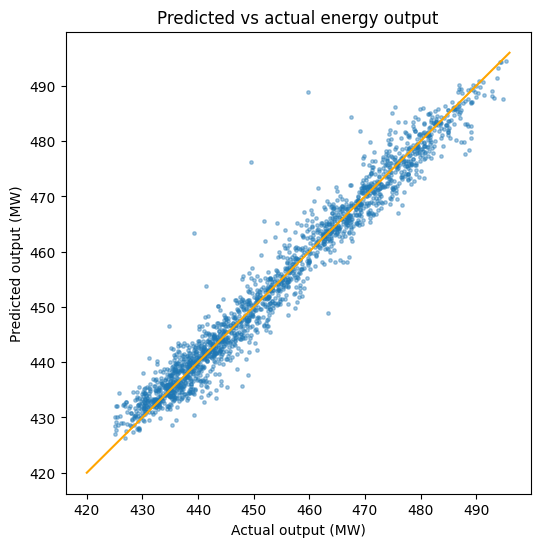

In [5]:
model, feats = models[best]
model.fit(X_train[feats], y_train)
pred = model.predict(X_test[feats])
print(f"MAE:  {mean_absolute_error(y_test, pred):.2f} MW")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.2f} MW")
print(f"MAPE: {mean_absolute_percentage_error(y_test, pred)*100:.2f}%")
print(f"R2:   {r2_score(y_test, pred):.3f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, s=6, alpha=0.4)
plt.plot([420, 496], [420, 496], color="orange")
plt.xlabel("Actual output (MW)")
plt.ylabel("Predicted output (MW)")
plt.title("Predicted vs actual energy output")
plt.show()

## 6. Interpretation

In [6]:
for f, i in sorted(zip(feats, model.feature_importances_), key=lambda x: -x[1]):
    print(f"{f}: {i:.3f}")

AT: 0.901
V: 0.062
AP: 0.018
RH: 0.018


The Random Forest predicts hourly output to within about 2.3 MW on average (roughly 0.5% error) and explains over 96% of the variation in output. Ambient temperature drives around 90% of its decisions, matching the physics: hotter air is less dense, so output falls.